输出目录: results_amc_validation/

Step 1: 加载GME训练数据
GME数据维度: (59146, 113)
时间范围: 2019-07-01 13:25:00 ~ 2021-06-30 23:55:00
正样本: 2565 (4.34%)
特征数: 102

Step 2: 训练LightGBM (Train on GME)

  Fitting scaler on GME data...
  Fitting scaler on GME raw data...
  ✓ Scaler fitted
  ✓ Scaler fitted on GME data
训练集: 41,816 样本 | 正样本: 1401 (3.35%)
验证集: 383 样本  | 正样本: 127 (33.16%)

✓ 训练完成
  GME验证集 PR-AUC: 0.4903 (参考基准)

Step 3: 加载AMC数据
AMC数据维度: (67510, 113)
时间范围: 2019-07-01 12:30:00 ~ 2021-07-01 00:00:00
正样本: 2820 (4.18%)

特征对齐:
  GME特征数: 102
  AMC特征数: 102
  共同特征数: 102

Step 4: AMC预测 (Test on AMC — External Validation)
  Scaling AMC data with GME scaler...
  ✓ AMC data scaled with GME scaler

  AMC External Validation Results:
  ─────────────────────────────────────────────
  PR-AUC:          0.3411  (vs random baseline 0.0418)
  ROC-AUC:         0.7191
  Improvement:     8.2× over random baseline
  Best threshold:  0.69

              precision    recall  f1-score   support

           0      0.971    

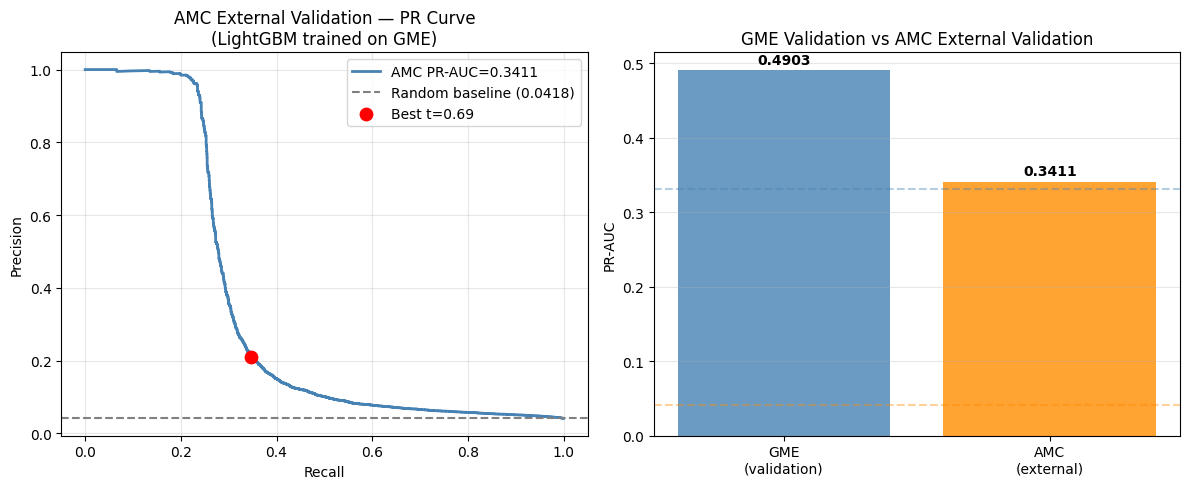

✓ 保存: results_amc_validation/amc_validation_results.png
✓ 保存: results_amc_validation/amc_daily_prediction.csv

AMC EXTERNAL VALIDATION COMPLETE

  Train: GME (up to 2021-01-25)
  Test:  AMC (full dataset)
  PR-AUC: 0.3411 (8.2× vs random baseline)
  ROC-AUC: 0.7191


In [5]:
"""
AMC External Validation
========================
Train on GME data → Predict on AMC data (External Validation)

逻辑:
  Step 1: 读GME merged data，用全部训练期训练LightGBM
  Step 2: 读AMC merged data，直接预测
  Step 3: 报告AMC的PR-AUC、ROC-AUC等指标

文件夹结构:
  amc_validation/
  ├── amc_predict.py              ← 本文件
  ├── data/
  │   ├── merged_data_scaled_CLEAN.parquet         ← GME数据
  │   ├── feature_groups_CLEAN.json                ← GME feature groups
  │   ├── merged_data_amc_scaled_CLEAN.parquet     ← AMC数据
  │   └── feature_groups_amc_CLEAN.json            ← AMC feature groups
  └── results_amc_validation/                      ← 输出
"""

import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, precision_recall_curve
)

# ── 配置 ──────────────────────────────────────────────────────────────────────
# GME（训练）— 直接读scaled文件，与主模型完全一致
GME_DATA_FILE     = 'data/merged_data_scaled_CLEAN.parquet'
GME_GROUPS_FILE   = 'data/feature_groups_CLEAN.json'

# GME raw文件 — 用来fit scaler
GME_RAW_FILE      = 'data/merged_data_raw_CLEAN.parquet'

# AMC（预测）— raw文件，用GME scaler标准化
AMC_DATA_FILE     = 'data/merged_data_amc_raw_CLEAN.parquet'
AMC_GROUPS_FILE   = 'data/feature_groups_amc_CLEAN.json'

TARGET      = 'EWS_15min'
RANDOM_SEED = 42

# GME训练/验证时间切割（与主实验一致）
GME_TRAIN_END = '2021-01-25 23:59:59'
GME_VAL_START = '2021-01-26 00:00:00'
GME_VAL_END   = '2021-01-27 23:59:59'

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

LGB_PARAMS = {
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
    'verbose': -1,
}

OUT_DIR = 'results_amc_validation'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'输出目录: {OUT_DIR}/')

# ── 1. 加载GME数据 ────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 1: 加载GME训练数据')
print('='*65)

gme_df = pd.read_parquet(GME_DATA_FILE)
gme_df['timestamp'] = pd.to_datetime(gme_df['timestamp'])
gme_df = gme_df.sort_values('timestamp').reset_index(drop=True)

with open(GME_GROUPS_FILE, 'r', encoding='utf-8') as f:
    gme_groups = json.load(f)

print(f'GME数据维度: {gme_df.shape}')
print(f'时间范围: {gme_df["timestamp"].min()} ~ {gme_df["timestamp"].max()}')
print(f'正样本: {int(gme_df[TARGET].sum())} ({gme_df[TARGET].mean()*100:.2f}%)')

# halt lag加入market组
halt_lag = [c for c in ['is_official_halt_lag1', 'is_official_halt_lag2']
            if c in gme_df.columns]
if halt_lag:
    gme_groups['market'] = list(gme_groups.get('market', [])) + halt_lag

# full_with_coordination特征
FULL_GROUPS = ['market', 'cascade', 'network', 'temporal', 'text',
               'burstiness', 'user_overlap', 'text_duplication']

def get_features(df, groups_dict, groups_list):
    feats = []
    for g in groups_list:
        feats.extend(groups_dict.get(g, []))
    feats = [f for f in dict.fromkeys(feats) if f in df.columns]
    feats = [f for f in feats if f not in LEAKAGE_FEATURES]
    return feats

gme_features = get_features(gme_df, gme_groups, FULL_GROUPS)
print(f'特征数: {len(gme_features)}')

# ── 2. 训练LightGBM（GME训练集）─────────────────────────────────────────────
print('\n' + '='*65)
print('Step 2: 训练LightGBM (Train on GME)')
print('='*65)

train_mask = gme_df['timestamp'] <= GME_TRAIN_END
val_mask   = (gme_df['timestamp'] >= GME_VAL_START) & \
             (gme_df['timestamp'] <= GME_VAL_END)

# 用GME全部数据fit scaler，再transform训练集和验证集
print('\n  Fitting scaler on GME data...')
# 直接用scaled文件的值训练，与主模型完全一致
X_train = gme_df.loc[train_mask, gme_features].fillna(0)
X_val   = gme_df.loc[val_mask,   gme_features].fillna(0)
y_train = gme_df.loc[train_mask, TARGET]
y_val   = gme_df.loc[val_mask,   TARGET]

# 用GME raw全部数据fit scaler（与Merge脚本一致），用于后续transform AMC
print('  Fitting scaler on GME raw data...')
gme_raw = pd.read_parquet(GME_RAW_FILE)
gme_raw['timestamp'] = pd.to_datetime(gme_raw['timestamp'])
scaler = StandardScaler()
scaler.fit(gme_raw[gme_features].fillna(0))
print('  ✓ Scaler fitted')

print('  ✓ Scaler fitted on GME data')

spw = (y_train == 0).sum() / y_train.sum()

print(f'训练集: {len(X_train):,} 样本 | 正样本: {int(y_train.sum())} ({y_train.mean()*100:.2f}%)')
print(f'验证集: {len(X_val):,} 样本  | 正样本: {int(y_val.sum())} ({y_val.mean()*100:.2f}%)')

model = lgb.LGBMClassifier(**LGB_PARAMS, class_weight={0: 1, 1: spw})
model.fit(X_train, y_train)

# GME验证集表现（作为参考基准）
y_prob_val = model.predict_proba(X_val)[:, 1]
gme_val_prauc = average_precision_score(y_val, y_prob_val)
print(f'\n✓ 训练完成')
print(f'  GME验证集 PR-AUC: {gme_val_prauc:.4f} (参考基准)')

# ── 3. 加载AMC数据 ────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 3: 加载AMC数据')
print('='*65)

amc_df = pd.read_parquet(AMC_DATA_FILE)
amc_df['timestamp'] = pd.to_datetime(amc_df['timestamp'])
amc_df = amc_df.sort_values('timestamp').reset_index(drop=True)

with open(AMC_GROUPS_FILE, 'r', encoding='utf-8') as f:
    amc_groups = json.load(f)

# halt lag加入market组
halt_lag_amc = [c for c in ['is_official_halt_lag1', 'is_official_halt_lag2']
                if c in amc_df.columns]
if halt_lag_amc:
    amc_groups['market'] = list(amc_groups.get('market', [])) + halt_lag_amc

print(f'AMC数据维度: {amc_df.shape}')
print(f'时间范围: {amc_df["timestamp"].min()} ~ {amc_df["timestamp"].max()}')
print(f'正样本: {int(amc_df[TARGET].sum())} ({amc_df[TARGET].mean()*100:.2f}%)')

# 用AMC里存在的特征（和GME特征对齐）
amc_features = get_features(amc_df, amc_groups, FULL_GROUPS)
common_features = [f for f in gme_features if f in amc_features]
missing_in_amc  = [f for f in gme_features if f not in amc_features]

print(f'\n特征对齐:')
print(f'  GME特征数: {len(gme_features)}')
print(f'  AMC特征数: {len(amc_features)}')
print(f'  共同特征数: {len(common_features)}')
if missing_in_amc:
    print(f'  AMC缺失特征: {missing_in_amc}')

# ── 4. AMC预测 ────────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 4: AMC预测 (Test on AMC — External Validation)')
print('='*65)

# 用GME scaler标准化AMC数据（确保分布一致）
print('  Scaling AMC data with GME scaler...')
amc_raw = amc_df[gme_features].copy()

# 补充GME有但AMC没有的特征（填0）
for feat in gme_features:
    if feat not in amc_raw.columns:
        amc_raw[feat] = 0
amc_raw = amc_raw[gme_features].fillna(0)

X_amc = pd.DataFrame(
    scaler.transform(amc_raw),
    columns=gme_features,
    index=amc_df.index
)
print('  ✓ AMC data scaled with GME scaler')

y_amc  = amc_df[TARGET]
y_prob = model.predict_proba(X_amc)[:, 1]

# 指标
pr_auc  = average_precision_score(y_amc, y_prob)
roc_auc = roc_auc_score(y_amc, y_prob)
random_baseline = y_amc.mean()

# 最优阈值
import numpy as np
thresholds = np.arange(0.02, 0.70, 0.01)
f1s    = [f1_score(y_amc, (y_prob >= t).astype(int), zero_division=0)
          for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
y_pred = (y_prob >= best_t).astype(int)

print(f'\n  AMC External Validation Results:')
print(f'  {"─"*45}')
print(f'  PR-AUC:          {pr_auc:.4f}  (vs random baseline {random_baseline:.4f})')
print(f'  ROC-AUC:         {roc_auc:.4f}')
print(f'  Improvement:     {pr_auc/random_baseline:.1f}× over random baseline')
print(f'  Best threshold:  {best_t:.2f}')
print(f'\n{classification_report(y_amc, y_pred, digits=3, zero_division=0)}')

# ── 5. 保存结果 ───────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 5: 保存结果')
print('='*65)

# 汇总表
summary = pd.DataFrame([{
    'dataset':        'AMC (External Validation)',
    'model':          'LightGBM (trained on GME)',
    'features':       'full_with_coordination',
    'n_features':     len(gme_features),
    'pr_auc':         round(pr_auc, 4),
    'roc_auc':        round(roc_auc, 4),
    'random_baseline': round(random_baseline, 4),
    'improvement_vs_baseline': round(pr_auc / random_baseline, 2),
    'best_threshold': round(best_t, 2),
    'f1_at_best_t':   round(f1_score(y_amc, y_pred, zero_division=0), 4),
    'precision':      round(precision_score(y_amc, y_pred, zero_division=0), 4),
    'recall':         round(recall_score(y_amc, y_pred, zero_division=0), 4),
    'gme_val_pr_auc': round(gme_val_prauc, 4),
}])

summary.to_csv(f'{OUT_DIR}/amc_validation_summary.csv', index=False)
print(f'✓ 保存: {OUT_DIR}/amc_validation_summary.csv')

# PR曲线图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

prec, rec, _ = precision_recall_curve(y_amc, y_prob)
axes[0].plot(rec, prec, color='steelblue', lw=2, label=f'AMC PR-AUC={pr_auc:.4f}')
axes[0].axhline(y=random_baseline, color='gray', linestyle='--',
                label=f'Random baseline ({random_baseline:.4f})')
axes[0].scatter(recall_score(y_amc, y_pred, zero_division=0),
                precision_score(y_amc, y_pred, zero_division=0),
                color='red', s=80, zorder=5, label=f'Best t={best_t:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('AMC External Validation — PR Curve\n(LightGBM trained on GME)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# GME vs AMC PR-AUC对比
models_compare = ['GME\n(validation)', 'AMC\n(external)']
prauc_compare  = [gme_val_prauc, pr_auc]
baseline_compare = [y_val.mean(), random_baseline]
bars = axes[1].bar(models_compare, prauc_compare,
                   color=['steelblue', 'darkorange'], alpha=0.8)
for i, (b, bl) in enumerate(zip(prauc_compare, baseline_compare)):
    axes[1].axhline(y=bl, color=['steelblue', 'darkorange'][i],
                    linestyle='--', alpha=0.4)
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('GME Validation vs AMC External Validation')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, prauc_compare):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/amc_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ 保存: {OUT_DIR}/amc_validation_results.png')

# 每日预测
result_df = amc_df[['timestamp', TARGET]].copy()
result_df['prob'] = y_prob
result_df['pred'] = y_pred
result_df['date'] = result_df['timestamp'].dt.date

daily = result_df.groupby('date').agg(
    true_events=(TARGET, 'sum'),
    predicted=('pred', 'sum'),
    max_prob=('prob', 'max'),
)
daily.to_csv(f'{OUT_DIR}/amc_daily_prediction.csv')
print(f'✓ 保存: {OUT_DIR}/amc_daily_prediction.csv')

print('\n' + '='*65)
print('AMC EXTERNAL VALIDATION COMPLETE')
print('='*65)
print(f'\n  Train: GME (up to 2021-01-25)')
print(f'  Test:  AMC (full dataset)')
print(f'  PR-AUC: {pr_auc:.4f} ({pr_auc/random_baseline:.1f}× vs random baseline)')
print(f'  ROC-AUC: {roc_auc:.4f}')